<a href="https://colab.research.google.com/github/RaihanDaffa04/PCVK_Ganjil2026/blob/main/Week05_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Raihan Daffa Izzuddin'
NIM = '244107020113'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Raihan Daffa Izzuddin
NIM    : 244107020113 | N = 113
bins   : 16
clip   : 2.5
tile   : 3
L      : 8
WAKTU  : 2026-10-03 20:53:55 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 96e555765165e2c0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [10]:
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE = '/content/drive/MyDrive/PCVK'

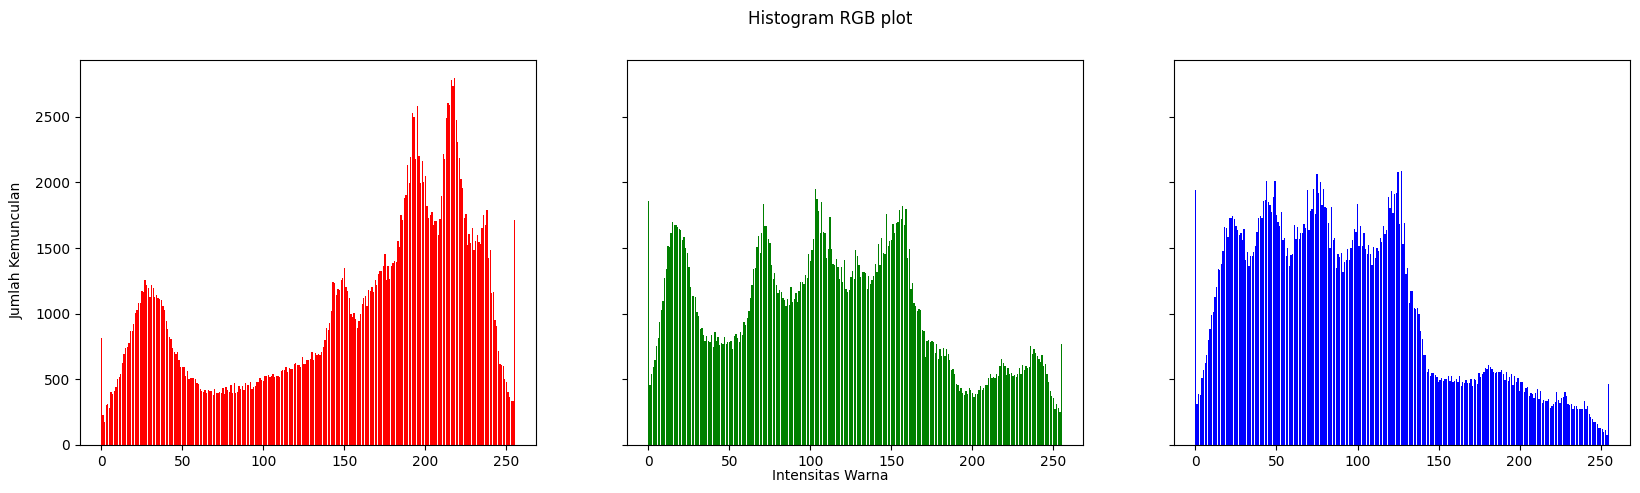

In [6]:
img = cv.imread(f"{CONTOH}/lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

plt.show()

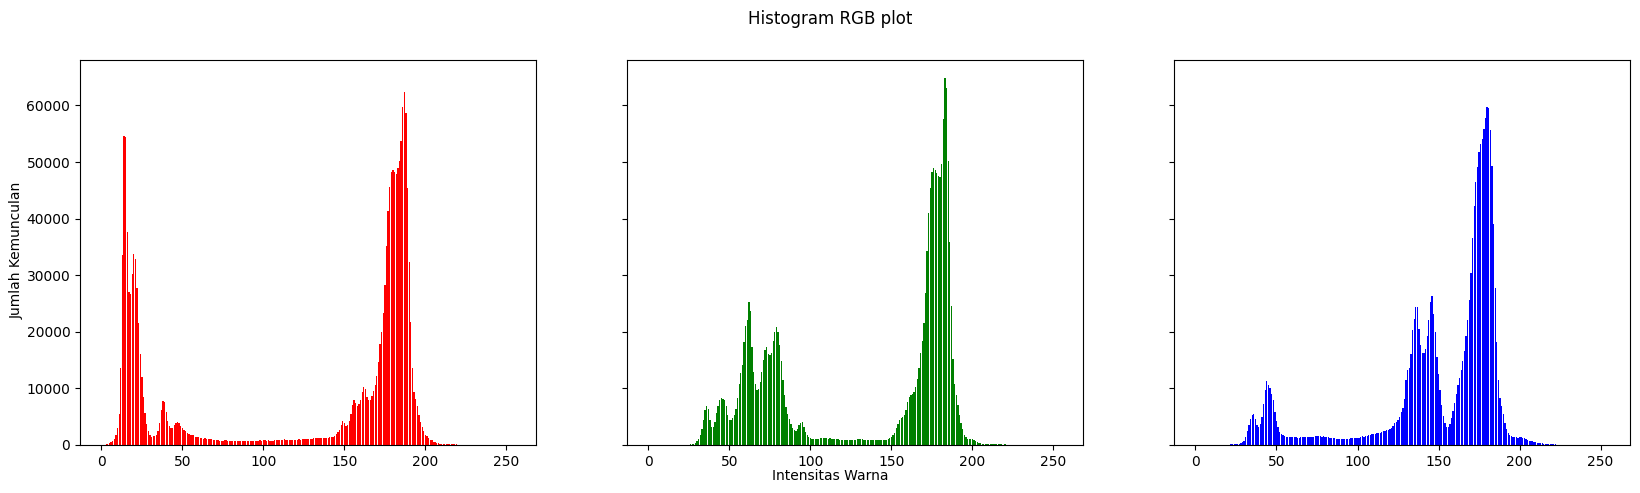

In [11]:
img = cv.imread(f"{BASE}/KTM1b.jpeg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

plt.show()

Pertanyaan Praktikum E1

In [14]:
import cv2 as cv
import numpy as np

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def bandingkan_histogram(path_citra, nama_citra):
    print(f"--- Pembuktian pada citra: {nama_citra} ---")
    img = cv.imread(path_citra, cv.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Gagal memuat citra dari {path_citra}. Pastikan path benar.")
        return

    hist_manual = histogram_manual(img)

    hist_numpy, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])

    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256])

    hist_cv = hist_cv.flatten().astype(np.int64)

    selisih_manual_np = np.max(np.abs(hist_manual - hist_numpy))
    selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    selisih_np_cv = np.max(np.abs(hist_numpy - hist_cv))

    print(f"Selisih maksimum Manual vs NumPy  : {selisih_manual_np}")
    print(f"Selisih maksimum Manual vs OpenCV : {selisih_manual_cv}")
    print(f"Selisih maksimum NumPy vs OpenCV  : {selisih_np_cv}")
    print("Pembuktian selesai.\n")

bandingkan_histogram(f"{CONTOH}/lena.jpg", "lena.jpg")

bandingkan_histogram(f"{BASE}/KTM1b.jpeg", "KTM1b.jpg")

--- Pembuktian pada citra: lena.jpg ---
Selisih maksimum Manual vs NumPy  : 0
Selisih maksimum Manual vs OpenCV : 0
Selisih maksimum NumPy vs OpenCV  : 0
Pembuktian selesai.

--- Pembuktian pada citra: KTM1b.jpg ---
Selisih maksimum Manual vs NumPy  : 0
Selisih maksimum Manual vs OpenCV : 0
Selisih maksimum NumPy vs OpenCV  : 0
Pembuktian selesai.



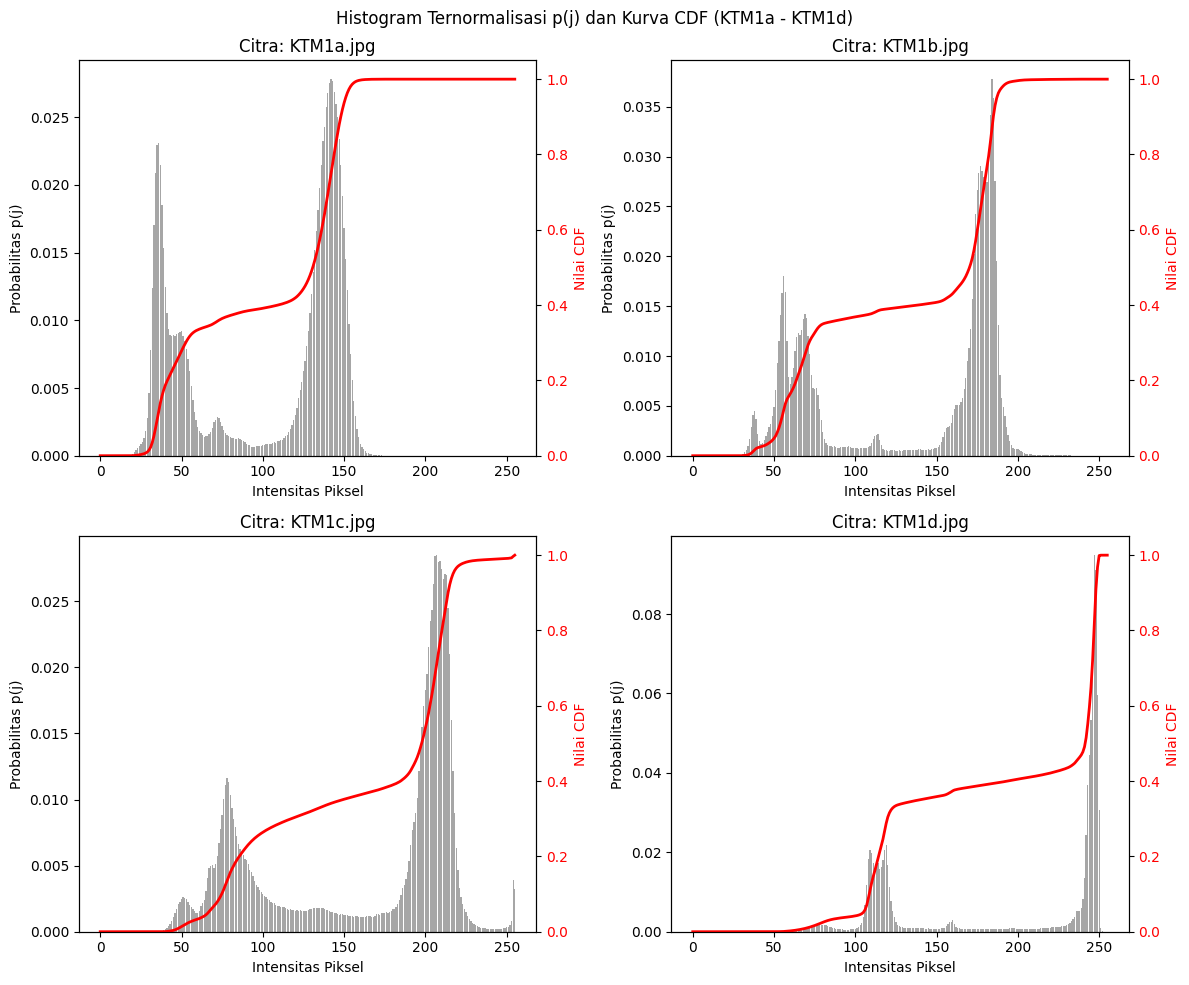

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Histogram Ternormalisasi p(j) dan Kurva CDF (KTM1a - KTM1d)')

ktm_list = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']
axs = axs.ravel()

for i, nama_ktm in enumerate(ktm_list):
    path_citra = f"{BASE}/{nama_ktm}.jpeg"
    img = cv.imread(path_citra, cv.IMREAD_GRAYSCALE)

    if img is None:
        axs[i].text(0.5, 0.5, f"Citra {nama_ktm} tidak ditemukan", ha='center', va='center')
        continue

    hist, bins = np.histogram(img.flatten(), 256, [0,256])

    pdf = hist / hist.sum()

    cdf = pdf.cumsum()

    axs[i].bar(np.arange(256), pdf, color='gray', alpha=0.7, label='p(j)')
    axs[i].set_title(f"Citra: {nama_ktm}.jpg")
    axs[i].set_xlabel('Intensitas Piksel')
    axs[i].set_ylabel('Probabilitas p(j)')

    ax2 = axs[i].twinx()
    ax2.plot(cdf, color='red', linewidth=2, label='CDF')
    ax2.set_ylabel('Nilai CDF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

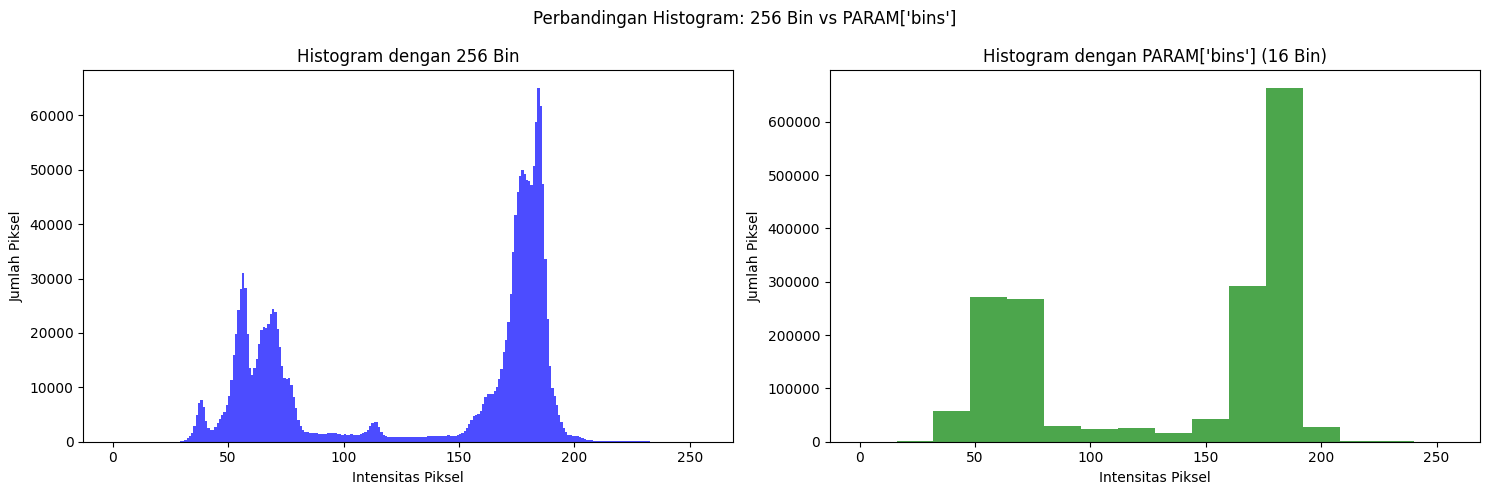

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm = f"{BASE}/KTM1b.jpeg"
img = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Perbandingan Histogram: 256 Bin vs PARAM['bins']")

axs[0].hist(img.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs[0].set_title('Histogram dengan 256 Bin')
axs[0].set_xlabel('Intensitas Piksel')
axs[0].set_ylabel('Jumlah Piksel')

jumlah_bin = PARAM['bins']
axs[1].hist(img.ravel(), bins=jumlah_bin, range=[0, 256], color='green', alpha=0.7)
axs[1].set_title(f"Histogram dengan PARAM['bins'] ({jumlah_bin} Bin)")
axs[1].set_xlabel('Intensitas Piksel')
axs[1].set_ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

Percobaan 2

 TAHAP 1: Citra Contoh 


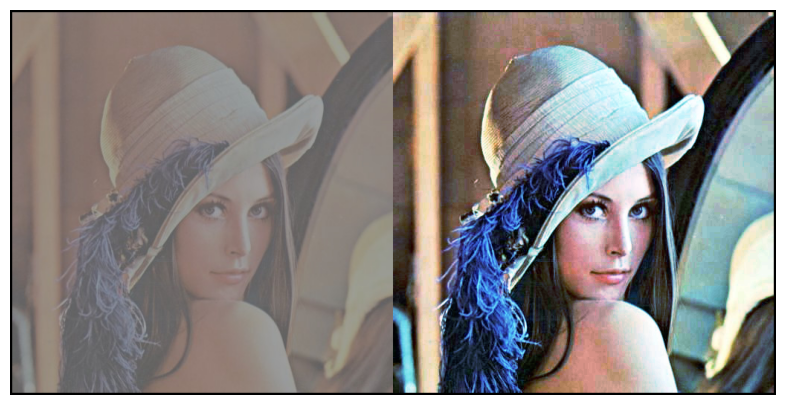

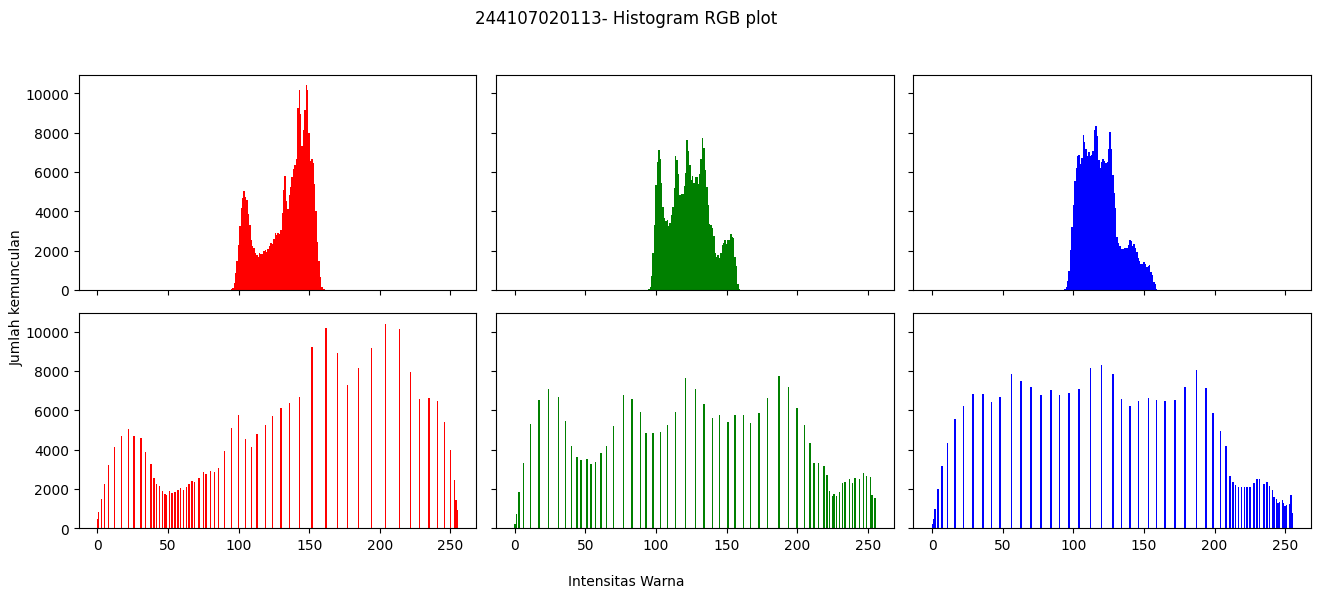

 TAHAP 2: Citra KTM 


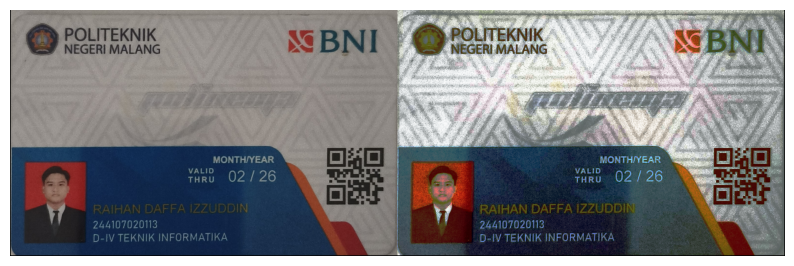

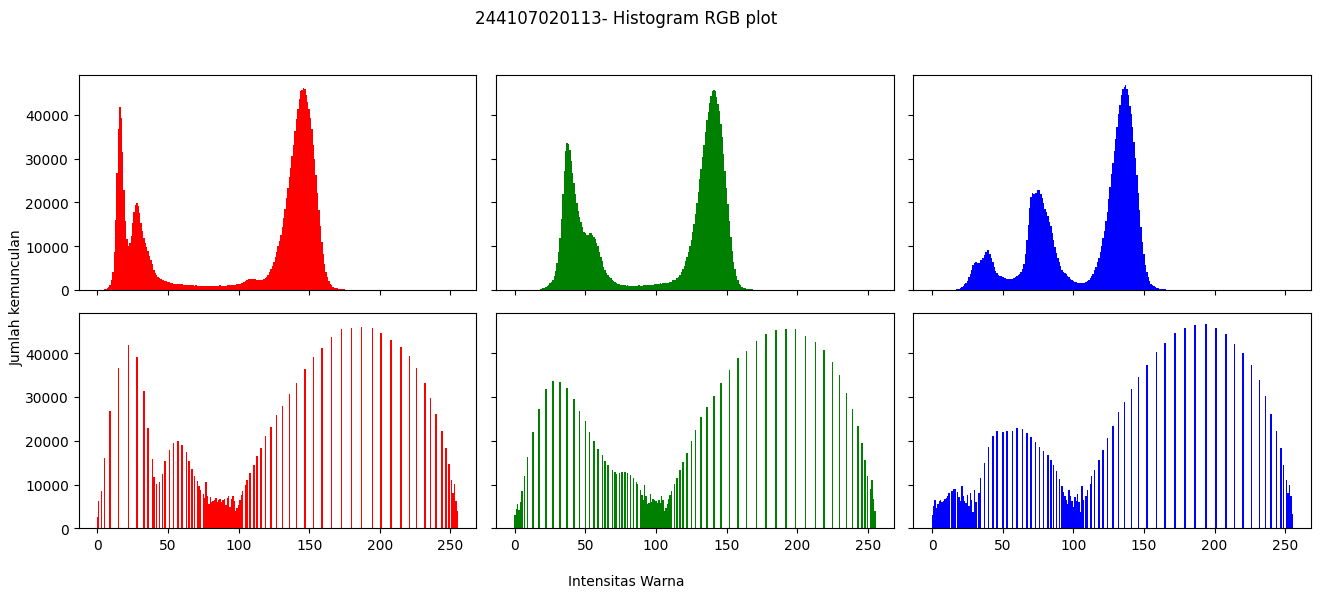

In [69]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_equalization_flowchart(img_channel):
    """
    Fungsi manual Histogram Equalization sesuai langkah-langkah pada flowchart.
    """
    height, width = img_channel.shape
    total_pixels = height * width

    frekuensi = np.zeros(256, dtype=np.int64)
    for y in range(height):
        for x in range(width):
            frekuensi[img_channel[y, x]] += 1

    kumulatif_frekuensi = frekuensi.cumsum()
    cdf_normalized = kumulatif_frekuensi / total_pixels

    K_b = 255
    lut = np.round(cdf_normalized * K_b).astype(np.uint8)

    img_equalized = lut[img_channel]

    return img_equalized, frekuensi, lut

def proses_e2_flowchart_lengkap(path_citra, nama_citra):
    img_bgr = cv.imread(path_citra)
    if img_bgr is None:
        print(f"Gagal memuat citra {nama_citra} dari: {path_citra}")
        return

    b, g, r = cv.split(img_bgr)

    b_eq, hist_b_orig, _ = histogram_equalization_flowchart(b)
    g_eq, hist_g_orig, _ = histogram_equalization_flowchart(g)
    r_eq, hist_r_orig, _ = histogram_equalization_flowchart(r)

    img_eq_bgr = cv.merge([b_eq, g_eq, r_eq])

    img_orig_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

    img_combined = np.hstack((img_orig_rgb, img_eq_rgb))
    img_combined_bordered = cv.copyMakeBorder(
        img_combined, top=3, bottom=3, left=3, right=3,
        borderType=cv.BORDER_CONSTANT, value=[0, 0, 0]
    )

    plt.figure(figsize=(10, 5))
    plt.imshow(img_combined_bordered)
    plt.axis('off')
    plt.show()

    names = np.arange(256)

    hist_r_eq, _ = np.histogram(r_eq.ravel(), 256, [0, 256])
    hist_g_eq, _ = np.histogram(g_eq.ravel(), 256, [0, 256])
    hist_b_eq, _ = np.histogram(b_eq.ravel(), 256, [0, 256])

    fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)
    fig.suptitle(NIM +'- Histogram RGB plot', fontsize=12)

    axs[0, 0].bar(names, hist_r_orig, color='red', width=1.0)
    axs[0, 1].bar(names, hist_g_orig, color='green', width=1.0)
    axs[0, 2].bar(names, hist_b_orig, color='blue', width=1.0)

    axs[1, 0].bar(names, hist_r_eq, color='red', width=1.0)
    axs[1, 1].bar(names, hist_g_eq, color='green', width=1.0)
    axs[1, 2].bar(names, hist_b_eq, color='blue', width=1.0)

    fig.text(0.06, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.02, 'Intensitas Warna', ha='center')

    plt.tight_layout(rect=[0.06, 0.05, 1, 0.95])
    plt.show()

print(" TAHAP 1: Citra Contoh ")
proses_e2_flowchart_lengkap(f"{CONTOH}/lena_lc.jpg", "lena_lc.jpg")

print(" TAHAP 2: Citra KTM ")
proses_e2_flowchart_lengkap(f"{BASE}/KTM1a.jpeg", "KTM1a.jpeg")

 Selisih maksimum manual vs equalizeHist: lena_lc.jpg
Kanal B: selisih maks = 0 | piksel berbeda = 0 dari 262144
Kanal G: selisih maks = 0 | piksel berbeda = 0 dari 262144
Kanal R: selisih maks = 0 | piksel berbeda = 0 dari 262144


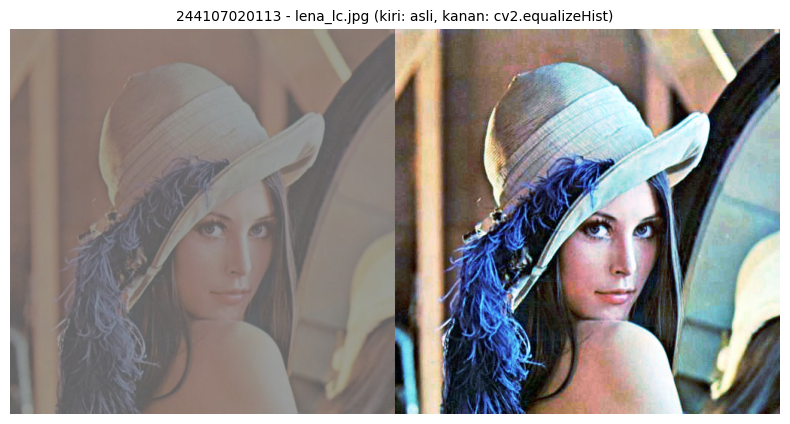

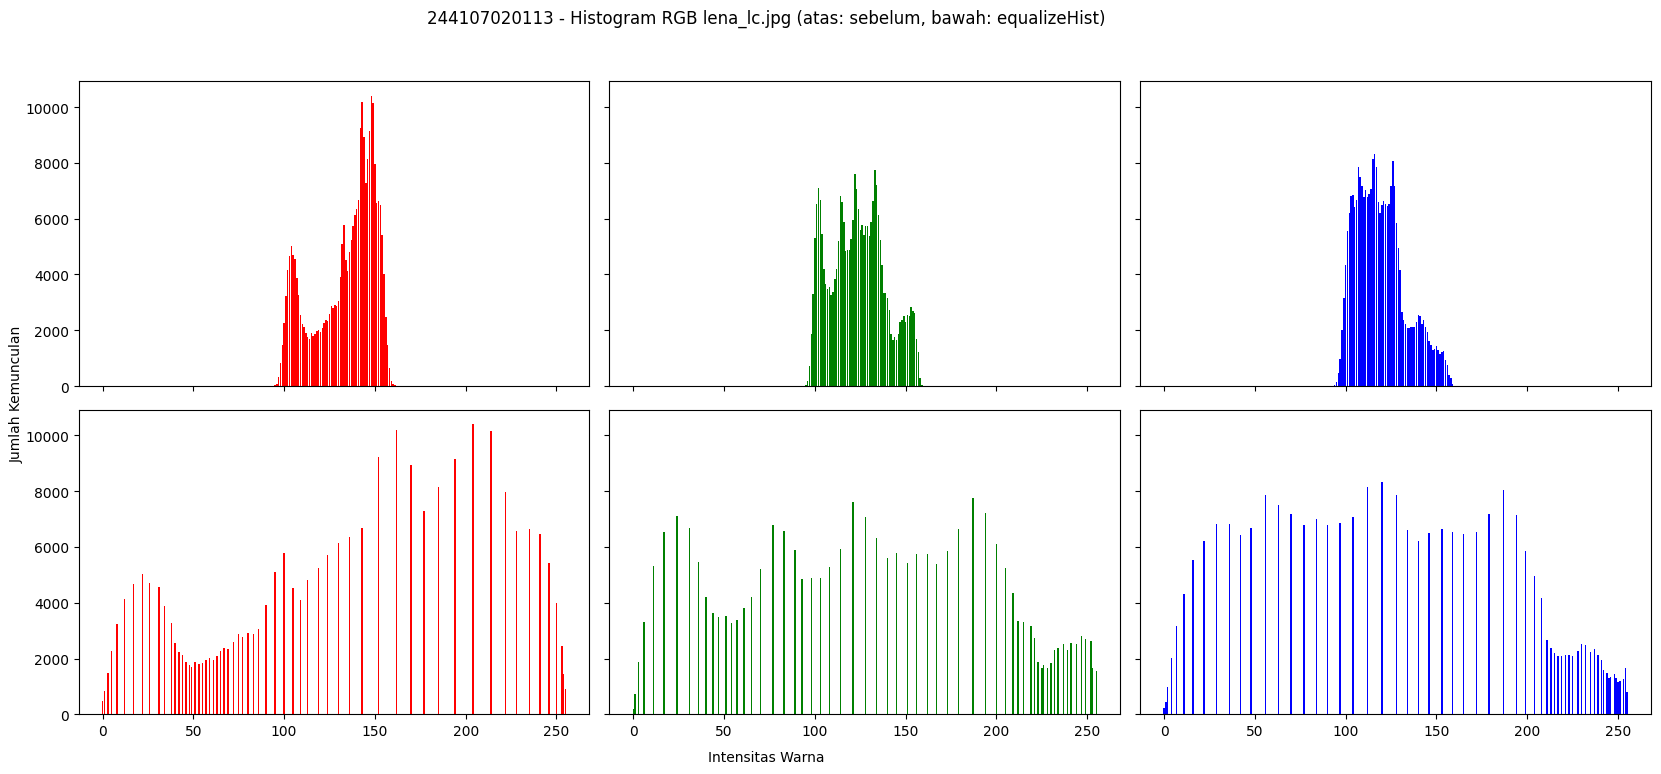

 Selisih maksimum manual vs equalizeHist: KTM1a.jpeg
Kanal B: selisih maks = 0 | piksel berbeda = 0 dari 1639571
Kanal G: selisih maks = 0 | piksel berbeda = 0 dari 1639571
Kanal R: selisih maks = 0 | piksel berbeda = 0 dari 1639571


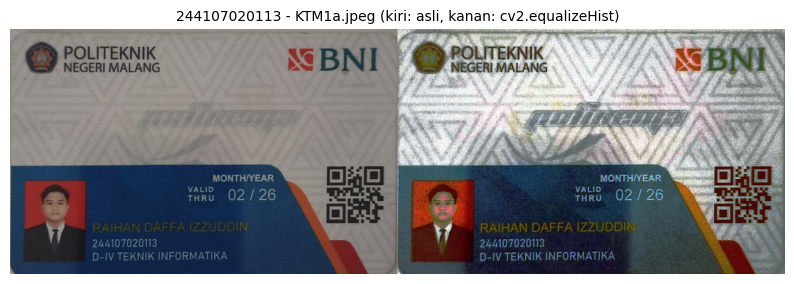

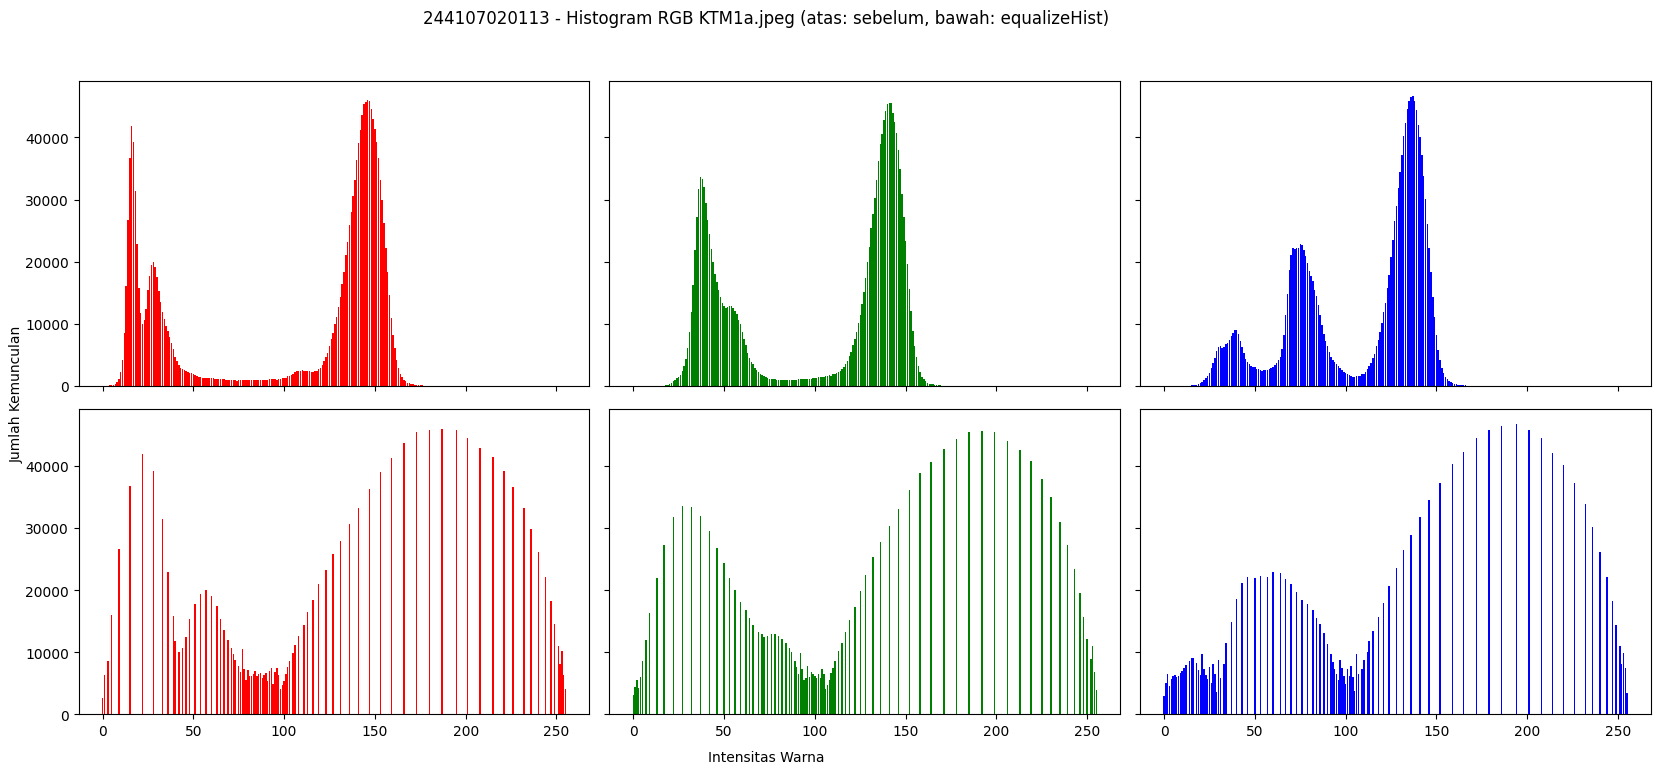

In [44]:
def equalize_cv2_rgb(path_citra, nama_citra):
    bgr = cv.imread(path_citra)
    if bgr is None:
        print(f"Gagal memuat citra: {path_citra}")
        return

    b, g, r = cv.split(bgr)

    b_cv, g_cv, r_cv = cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)
    he_cv = cv.merge([b_cv, g_cv, r_cv])

    b_mn, g_mn, r_mn = equalize_manual(b), equalize_manual(g), equalize_manual(r)

    print("=" * 50)
    print(" Selisih maksimum manual vs equalizeHist:", nama_citra)
    print("=" * 50)
    for nama, mn, cvr in [('B', b_mn, b_cv), ('G', g_mn, g_cv), ('R', r_mn, r_cv)]:
        d = np.abs(mn.astype(np.int16) - cvr.astype(np.int16))
        print(f"Kanal {nama}: selisih maks = {d.max()} | piksel berbeda = {(d > 0).sum()} dari {d.size}")

    gabung = np.hstack([bgr, he_cv])
    plt.figure(figsize=(10, 5))
    plt.imshow(cv.cvtColor(gabung, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + nama_citra + ' (kiri: asli, kanan: cv2.equalizeHist)', fontsize=10)
    plt.axis('off')
    plt.show()

    # --- histogram RGB 2x3 ---
    names = np.arange(256)
    fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
    fig.suptitle(NIM + ' - Histogram RGB ' + nama_citra + ' (atas: sebelum, bawah: equalizeHist)')
    for j, (asli, eq, warna) in enumerate([(r, r_cv, 'red'), (g, g_cv, 'green'), (b, b_cv, 'blue')]):
        axs[0, j].bar(names, hist_manual(asli), color=warna)
        axs[1, j].bar(names, hist_manual(eq),   color=warna)
    fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
    plt.tight_layout(rect=[0.08, 0.05, 1, 0.95])
    plt.show()

equalize_cv2_rgb(f"{CONTOH}/lena_lc.jpg", "lena_lc.jpg")
equalize_cv2_rgb(f"{BASE}/KTM1a.jpeg", "KTM1a.jpeg")

TAHAP 1: Citra Contoh


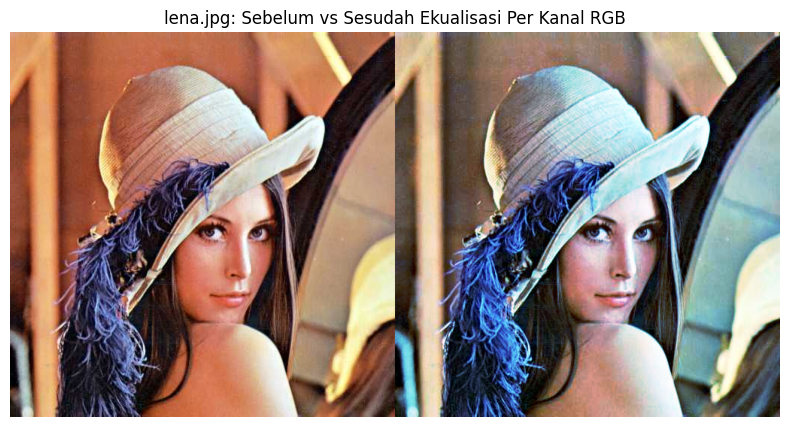

TAHAP 2: Citra KTM


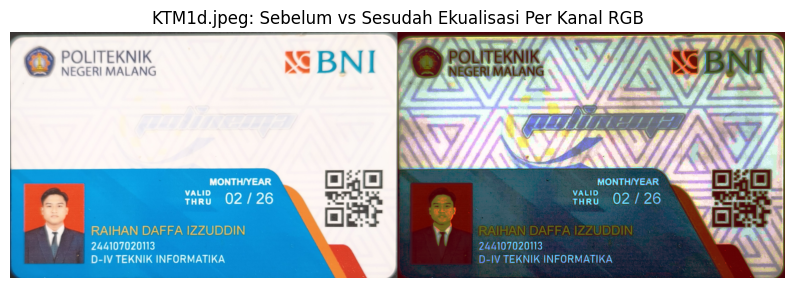

In [48]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def proses_ekualisasi_rgb_per_kanal(path_citra, nama_citra):
    bgr = cv.imread(path_citra)
    if bgr is None:
        print(f"Gagal memuat citra dari {path_citra}")
        return

    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    bgr_display = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    he_display = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)

    gabungan = np.hstack((bgr_display, he_display))

    plt.figure(figsize=(10, 5))
    plt.imshow(gabungan)
    plt.title(f"{nama_citra}: Sebelum vs Sesudah Ekualisasi Per Kanal RGB")
    plt.axis('off')
    plt.show()

print("TAHAP 1: Citra Contoh")
proses_ekualisasi_rgb_per_kanal(f"{CONTOH}/lena.jpg", "lena.jpg")


print("TAHAP 2: Citra KTM")
proses_ekualisasi_rgb_per_kanal(f"{BASE}/KTM1d.jpeg", "KTM1d.jpeg")

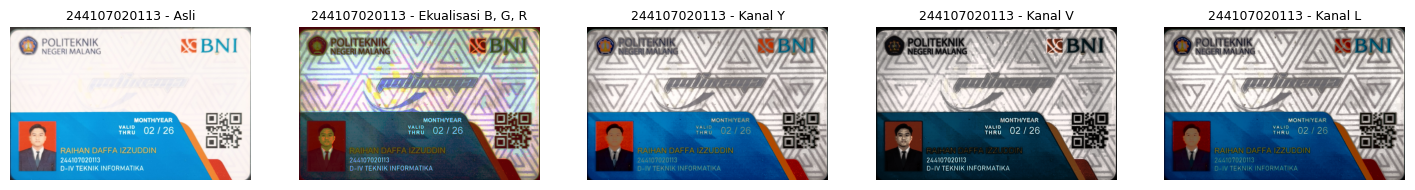

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            193.2
Ekualisasi B, G, R                56.15            132.3
Kanal Y                            2.94            136.9
Kanal V                            3.33            119.9
Kanal L                            6.07            127.2


In [57]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = BASE + '/KTM1d.jpeg'

bgr = cv.imread(berkas, cv.IMREAD_COLOR)

if bgr is None:
    print(f"Gagal memuat citra dari path: {berkas}")
else:
    if len(bgr.shape) == 2:
        bgr = cv.cvtColor(bgr, cv.COLOR_GRAY2BGR)

    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)


    ycrcb     = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y      = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv       = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v      = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab       = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b_c = cv.split(lab)
    he_l      = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_c]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.show()


    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d  = np.abs(h1 - h2)
        d  = np.minimum(d, 180 - d)
        return d.mean()

    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                       cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Kanal Y (equalizeHist)   geser Hue = 2.94 derajat | rerata terang = 136.9
Kanal Y (CLAHE)          geser Hue = 0.16 derajat | rerata terang = 185.0


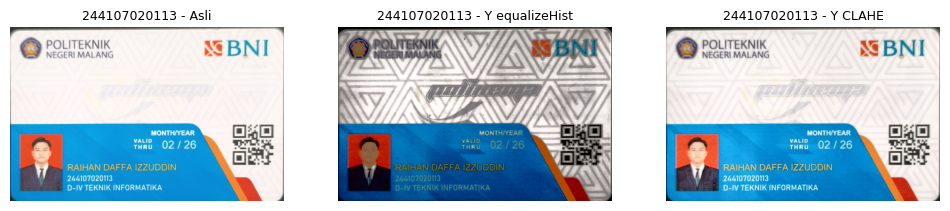

In [58]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_y_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

for t, c in [('Kanal Y (equalizeHist)', he_y), ('Kanal Y (CLAHE)', he_y_clahe)]:
    print('%-24s geser Hue = %.2f derajat | rerata terang = %.1f' % (
        t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

plt.figure(figsize=(12, 4))
for i, (c, t) in enumerate([(bgr, 'Asli'), (he_y, 'Y equalizeHist'), (he_y_clahe, 'Y CLAHE')], 1):
    plt.subplot(1, 3, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

Selisih maksimum manual vs equalizeHist: 0


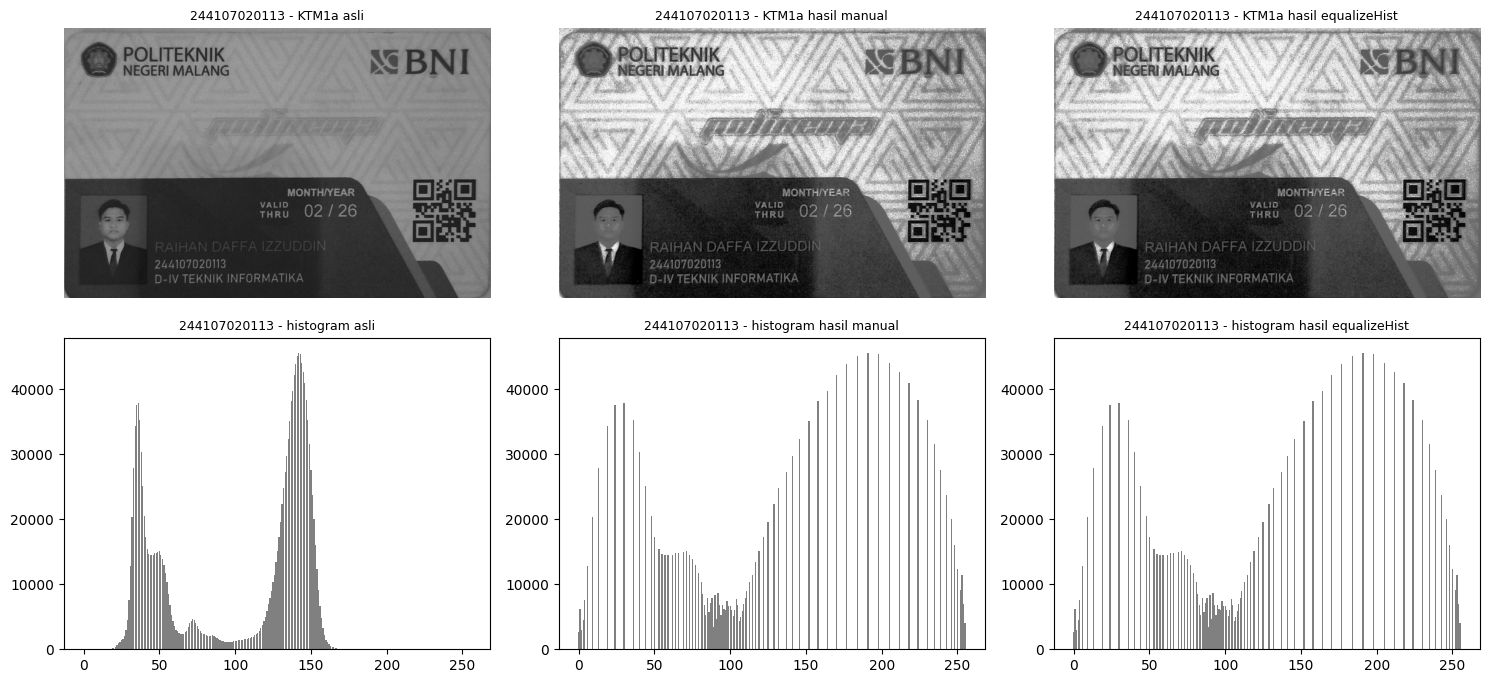

PSNR asli vs manual      : 15.37 dB
PSNR asli vs equalizeHist: 15.37 dB
Simpangan baku (kontras): asli 47.0 -> manual 74.0


In [60]:
gray_k = cv.imread(BASE + '/KTM1a.jpeg', cv.IMREAD_GRAYSCALE)
assert gray_k is not None, 'KTM1a.jpeg tidak ditemukan'

he_man = equalize_manual(gray_k)
he_cv  = cv.equalizeHist(gray_k)

print('Selisih maksimum manual vs equalizeHist:',
      np.abs(he_man.astype(np.int16) - he_cv.astype(np.int16)).max())

data = [(gray_k, 'asli'), (he_man, 'hasil manual'), (he_cv, 'hasil equalizeHist')]
fig, axs = plt.subplots(2, 3, figsize=(15, 7))
for j, (im, t) in enumerate(data):
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
    axs[0, j].set_title(NIM + ' - KTM1a ' + t, fontsize=9)
    axs[0, j].axis('off')
    axs[1, j].bar(np.arange(256), np.bincount(im.ravel(), minlength=256), color='gray')
    axs[1, j].set_title(NIM + ' - histogram ' + t, fontsize=9)
plt.tight_layout()
plt.show()

print('PSNR asli vs manual      : %.2f dB' % cv.PSNR(gray_k, he_man))
print('PSNR asli vs equalizeHist: %.2f dB' % cv.PSNR(gray_k, he_cv))
print('Simpangan baku (kontras): asli %.1f -> manual %.1f' % (gray_k.std(), he_man.std()))

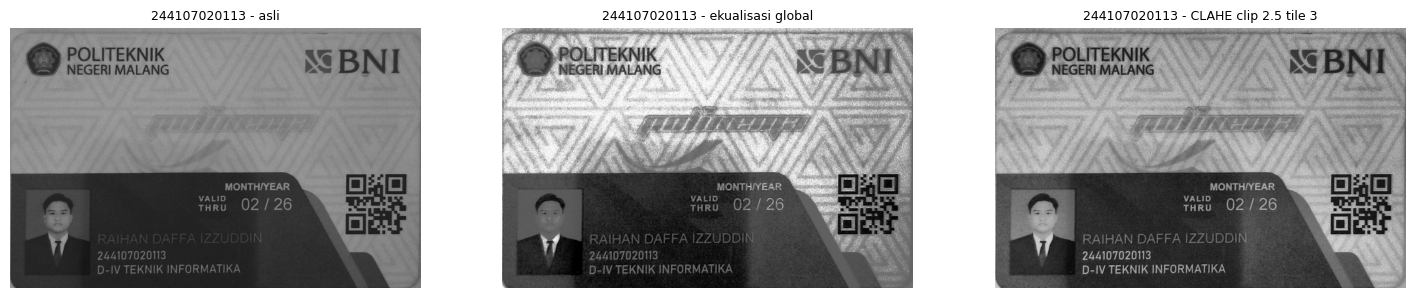

In [63]:
clahe    = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_clahe = clahe.apply(gray_k)

plt.figure(figsize=(18, 5))
for i, (im, t) in enumerate([(gray_k, 'asli'),
                             (he_cv, 'ekualisasi global'),
                             (he_clahe, 'CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']))], 1):
    plt.subplot(1, 3, i)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

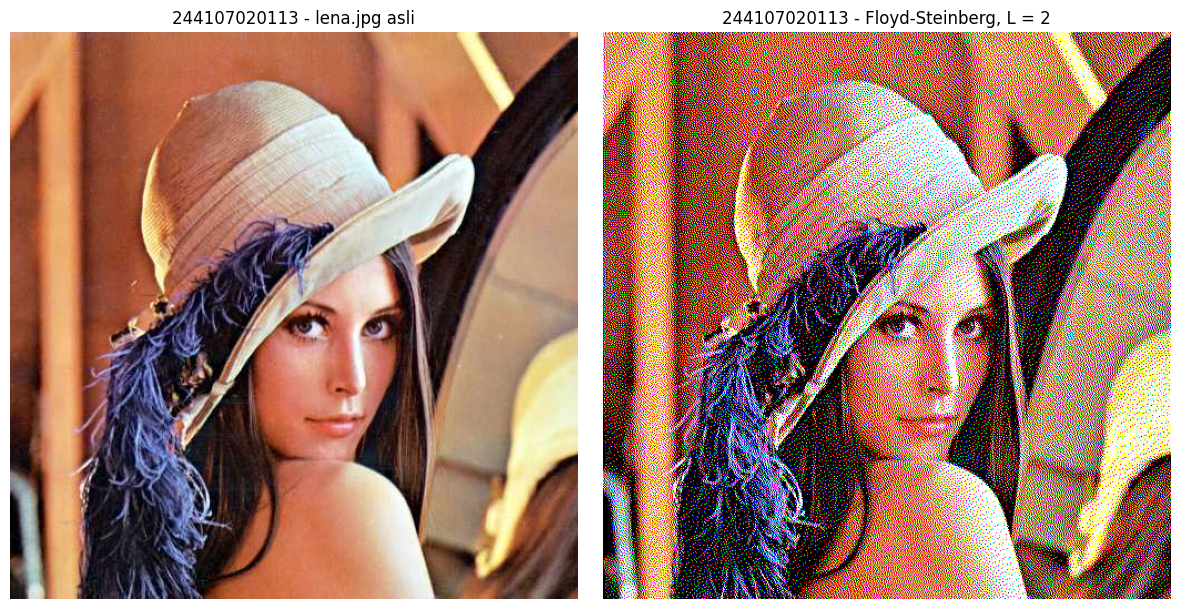

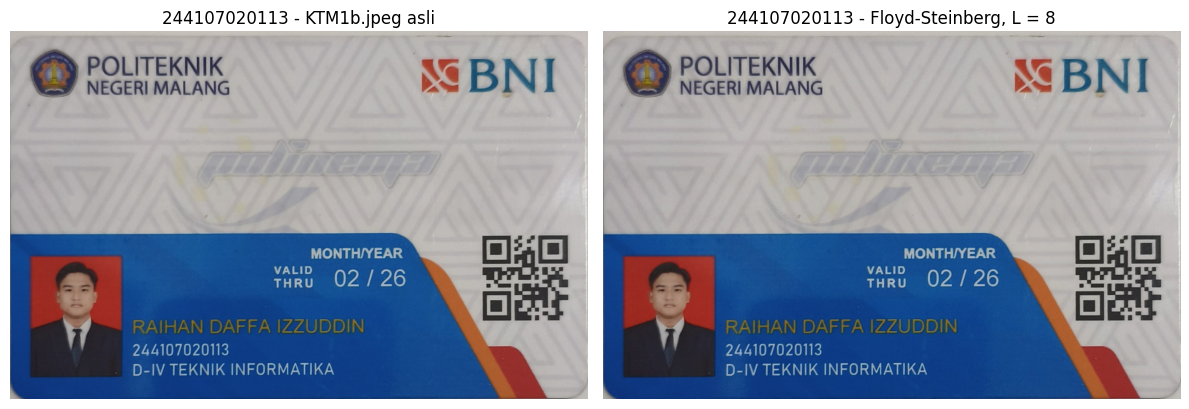

In [71]:
def floyd_steinberg_warna(bgr, L=2):
    # jalankan fungsi yang sama pada tiap kanal B, G, R lalu gabungkan
    kanal = [floyd_steinberg(bgr[:, :, i], L) for i in range(3)]
    return cv.merge(kanal)

def tampil_dither_warna(path, L, nama):
    bgr = cv.imread(path)
    assert bgr is not None, 'Citra tidak ditemukan: ' + path
    hasil = floyd_steinberg_warna(bgr, L)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(cv.cvtColor(bgr,   cv.COLOR_BGR2RGB)); axs[0].set_title(NIM + ' - ' + nama + ' asli')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); axs[1].set_title(NIM + ' - Floyd-Steinberg, L = %d' % L)
    for a in axs: a.axis('off')
    plt.tight_layout()
    plt.show()
    return hasil

_ = tampil_dither_warna(CONTOH + '/lena.jpg', 2, 'lena.jpg')

_ = tampil_dither_warna(BASE + '/KTM1b.jpeg', PARAM['L'], 'KTM1b.jpeg')

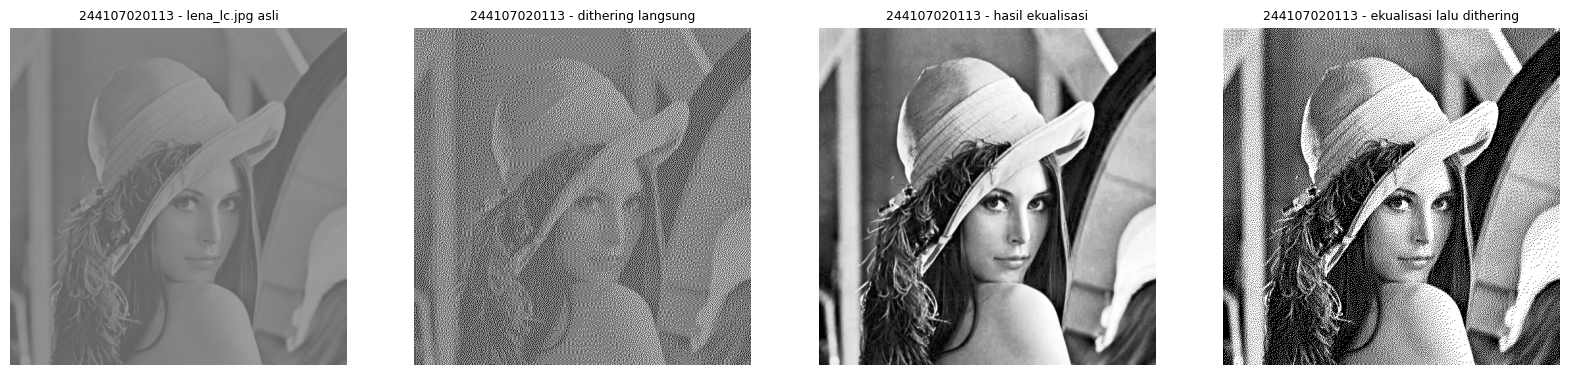

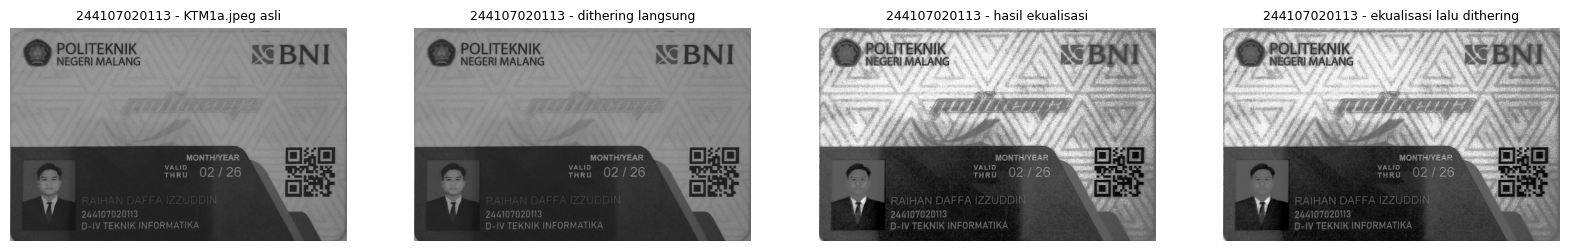

In [68]:
def e3_no2(gray, L, nama):
    langsung = floyd_steinberg(gray, L)
    eq       = equalize_manual(gray)
    eq_dith  = floyd_steinberg(eq, L)
    panel = [(gray, nama + ' asli'), (langsung, 'dithering langsung'),
             (eq, 'hasil ekualisasi'), (eq_dith, 'ekualisasi lalu dithering')]
    plt.figure(figsize=(20, 5))
    for i, (im, t) in enumerate(panel, 1):
        plt.subplot(1, 4, i)
        plt.imshow(im, cmap='gray', vmin=0, vmax=255)
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.show()

lena_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
e3_no2(lena_lc, 2, 'lena_lc.jpg')

e3_no2(gray_k, PARAM['L'], 'KTM1a.jpeg')